# Search: Solving a Maze Using a Goal-based Agent

Student Name: [Nguyễn Trọng Phúc]

I have used the following AI tools: [list tools]

I understand that my submission needs to be my own work: [NTP]

## Learning Outcomes

* Formulate search problems using key components like initial state, actions, and goal state in a deterministic, fully observable environment.
* Implement and compare search algorithms including BFS, DFS, GBFS, A*, and IDS for planning paths through mazes.
* Analyze algorithm performance by measuring path cost, node expansions, depth, and memory usage across various maze types.
* Use visualization tools to represent maze paths and support debugging and analysis.

## Instructions

Total Points: Undergrads 100 + 5 bonus / Graduate students 110

Complete this notebook. Use the provided notebook cells and insert additional code and markdown cells as needed. Submit the notebook file and the completely rendered notebook with all outputs as a HTML file. 


## Introduction

In this exercise, we will implement the planning function for a type of goal-based agent called a __planning agent__. The planning function uses a map it is given to plan a path through the maze from the starting location $S$ to the goal location $G$. We will only focus on the planning function, so you do not need to implement an environment, just use the map to search for a path to solve the maze. 

Once the plan is made, the agent in a deterministic environment (i.e., the transition function is deterministic with the outcome of each state/action pair fixed and no randomness) can just follow the plan step-by-step and does not need to care about the percepts.
This is also called an **[open-loop system](https://en.wikipedia.org/wiki/Open-loop_controller).**
The execution phase is trivial and can be executed using a model-based reflex agent 
that ignores all percepts and just follows the plan. I will show you a short example, but you do not implement it in this exercise.

Given that the agent has a complete and correct map, the environment is **fully observable, discrete, deterministic, and known.** 
Remember:

* **Fully observable** means that the agent can see its state and what the available actions are. That means the **percepts contain the complete current state.**
Here, during planning, the agent always sees its x and y coordinates on the map and
also seeks when it has reached the goal state. 
* **Discrete** means that we have a **finite set of states.** The maze has a finite set 
of squares the agent can be in.
* **Deterministic** means that the **transition function contains no randomness.** An action in a state will always produce the same result. Going south from the start state always will lead to the same square.
* **Know** means that the agent **knows the complete transition function.** The 
agent has the map and therefore knows how its position changes when it walks in a direction.

Tree search algorithm implementations that you find online typically come from data structures courses and have a different aim than AI tree search. These algorithms assume that you already have a tree in memory. We are interested in dynamically creating a search tree with the aim of finding a good/the best path from the root note to the goal state. Follow the pseudo code presented in the text book (and replicated in the slides) closely. Ideally, we would like to search only a small part of the maze, i.e., create a search tree with as few nodes as possible. 

Several mazes for this exercise are stored as text files. We need to make sure that they are locally available.

In [35]:
# change directory to Google Drive for Google Colab
try:
    from google.colab import drive
    import os

    drive.mount('/content/drive')
    os.chdir('/content/drive/My Drive/Colab Notebooks/')
    print("Your working directory is now Google Drive: My Drive > Colab Notebooks")
except ImportError:
    pass

In [36]:
import urllib.request
import os

def download(file, base_url):
    if not os.path.exists(file):
        urllib.request.urlretrieve(base_url + file, file)

base_url = "https://raw.githubusercontent.com/mhahsler/Introduction_to_Artificial_Intelligence/refs/heads/master/Search/"
download("maze_helper.py", base_url)

mazes = ["small_maze.txt", "medium_maze.txt", "large_maze.txt", "L_maze.txt", "empty_maze.txt", "empty_maze_2.txt", "loops_maze.txt", "open_maze.txt", ]
for maze in mazes:
    download(maze, base_url)

Here is the small example maze:

In [37]:
with open("small_maze.txt", "r") as f:
    maze_str = f.read()
print(maze_str)

XXXXXXXXXXXXXXXXXXXXXX
X XX        X X      X
X    XXXXXX X XXXXXX X
XXXXXX     S  X      X
X    X XXXXXX XX XXXXX
X XXXX X         X   X
X        XXX XXX   X X
XXXXXXXXXX    XXXXXX X
XG         XX        X
XXXXXXXXXXXXXXXXXXXXXX



**Note:** If you get an error here that the file cannot be found, then you need to download it. See [HOWTO Work on Assignments.](https://github.com/mhahsler/CS7320-AI/blob/master/HOWTOs/working_on_assignments.md)

## Parsing and pretty printing the maze

The maze can also be displayed in color using code in the module [maze_helper.py](maze_helper.py). The code parses the string representing the maze and converts it into a `numpy` 2d array which you can use in your implementation. Position are represented as a 2-tuple of the form `(row, col)`. 

In [38]:
import maze_helper as mh

maze = mh.parse_maze(maze_str)

# look at a position in the maze by subsetting the 2d array
print("Position(0,0):", maze[0, 0])

# there is also a helper function called `look(maze, pos)` available
# which uses a 2-tuple for the position.
print("Position(8,1):", mh.look(maze, (8, 1)))

Position(0,0): X
Position(8,1): G


A helper function to visualize the maze is also available.

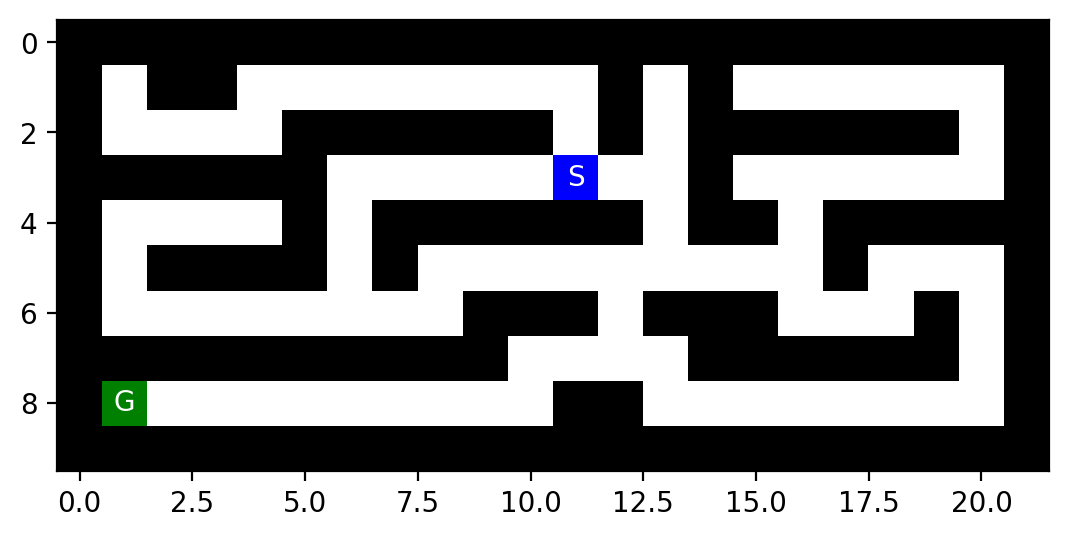

In [39]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
# use higher resolution images in notebooks

mh.show_maze(maze)

Find the `(x,y)` position of the start and the goal using the helper function `find_pos()`

In [40]:
print("Start location:", mh.find_pos(maze, what = "S"))
print("Goal location:", mh.find_pos(maze, what = "G"))

Start location: (np.int64(3), np.int64(11))
Goal location: (np.int64(8), np.int64(1))


Helper function documentation.

In [41]:
help(mh)

Help on module maze_helper:

NAME
    maze_helper

DESCRIPTION
    Code for the Maze Assignment
    Usage:
        import maze_helper as mh
        mh.show_some_mazes()

FUNCTIONS
    animate_maze(result, repeat=False)
        (Experimental) Build an animation from a list of mazes.

        Parameters:
            result: a list with the elements path, reached, actions and maze_anim with a list of maze arrays that contain what you want to visualize.
            repeat: if True, the animation will repeat.

    find_pos(maze, what='S')
        Find start/goal in a maze and returns the first one.
        Caution: there is no error checking!

        Parameters:
            maze: a array with characters produced by parse_maze()
            what: the letter to be found ('S' for start and 'G' for goal)

        Returns:
            a tupple (x, y) for the found position.

    look(maze, pos)
        Look at the label of a square with the position as an array of the form (x, y).

        Para

You will need to make a local copy of the module file [maze_helper.py](maze_helper.py) in the same folder where your notebook is.

## An Example for a Planning Agent

I will show you here how to implement a simple agent that uses a random plan. It will not solve the maze, but show you how the mechanics work.

First, we define a generic planning agent that fist plans, and then executes the plan step-by-step. 

In [42]:
class Planning_Agent:
    def __init__(self, maze, start, goal, planning_function):
        self.maze = maze
        self.start = start
        self.goal = goal
        self.planning_function = planning_function
        self.plan = None
        self.progress = None

    def act(self):
        # plan if no plan exists
        if self.plan is None:
            print("Planning...")
            self.plan = self.planning_function(self.maze, self.start, self.goal)
            self.progress = 0
        
        # check if plan is completed
        if self.progress >= len(self.plan):        
            raise Exception("Completed Plan. No more planned actions")
        
        # follow the plan
        action = self.plan[self.progress]
        print(f"Following plan... step {self.progress}: {action}")

        self.progress += 1
        return action

Next, we define the planning function. This function is what you will implement in this assignment.  

In [43]:
import numpy as np

def plan_random(maze, start, goal):
    """Create a random plan with 10 steps"""
    plan = np.random.choice(["N", "E", "S", "W"], size=10, replace=True).tolist()
    return plan

plan_random(maze, (1,1), (8,8))

['E', 'W', 'N', 'N', 'S', 'W', 'W', 'E', 'N', 'E']

This planning function is not great and will not produce a plan that solves the maze. Your planning functions will do better.

Finally, we can create the planning agent, give it the planning function and implement a simple environment that asks it 11 times for an action.

In [44]:
my_agent = Planning_Agent(maze, mh.find_pos(maze, what = "S"), mh.find_pos(maze, what = "G"), plan_random)

def environment(agent_function, steps):
    for _ in range(steps):
        try:
            agent_function()
        except Exception as e:
            print(f"Agent exception: {e}")

environment(my_agent.act, steps=11)

Planning...
Following plan... step 0: S
Following plan... step 1: W
Following plan... step 2: N
Following plan... step 3: E
Following plan... step 4: E
Following plan... step 5: W
Following plan... step 6: E
Following plan... step 7: S
Following plan... step 8: E
Following plan... step 9: S
Agent exception: Completed Plan. No more planned actions


Note: The agent and environment implementation above is just an illustration. You will only implement and experiment with different versions of the planning function.

## Tree structure

To use tree search, you will need to implement a tree data structure in Python. 
Here is an implementation of the basic node structure for the search algorithms (see Fig 3.7 on page 73). I have added a method that extracts the path from the root node to the current node. It can be used to get the path when the search is completed.

In [45]:
class Node:
    def __init__(self, pos, parent, action, cost):
        self.pos = tuple(pos)    # the state; positions are (row,col)
        self.parent = parent     # reference to parent node. None means root node.
        self.action = action     # action used in the transition function (root node has None)
        self.cost = cost         # for uniform cost this is the depth. It is also g(n) for A* search

    def __str__(self):
        return f"Node - pos = {self.pos}; action = {self.action}; cost = {self.cost}"
    
    def get_path_from_root(self):
        """returns nodes on the path from the root to the current node."""
        node = self
        path = [node]
    
        while not node.parent is None:
            node = node.parent
            path.append(node)
        
        path.reverse()
        
        return(path)

If needed, then you can add more fields to the class like the heuristic value $h(n)$ or $f(n)$.

Examples for how to create and use a tree and information on memory management can be found [here](../HOWTOs/trees.ipynb).

# Tasks

The goal is to:

1. Implement the following search algorithms for solving different mazes:

    - Breadth-first search (BFS)
    - Depth-first search (DFS)
    - Greedy best-first search (GBFS)
    - A* search

2. Run each of the above algorithms on the 
    - [small maze](small_maze.txt), 
    - [medium maze](medium_maze.txt), 
    - [large maze](large_maze.txt), 
    - [open maze](open_maze.txt),
    - [L maze](L_maze.txt),
    - [loops maze](loops_maze.txt),
    - [empty maze](empty_maze.txt), and
    - [empty maze (rotated)](empty_maze_2.txt).
    
3. For each problem instance and each search algorithm, report the following in a table:

    - The solution and its path cost
    - Total number of nodes expanded
    - Maximum tree depth
    - Maximum size of the frontier

4. Display each solution by marking every maze square (or state) visited and the squares on the final path.

## General [10 Points]

1. Make sure that you use the latest version of this notebook.
2. Your implementation can use libraries like math, numpy, scipy, but not libraries that implement intelligent agents or complete search algorithms. Try to keep the code simple! In this course, we want to learn about the algorithms and we often do not need to use object-oriented design.
3. You notebook needs to be formatted professionally. 
    - Add additional markdown blocks for your description, comments in the code, add tables and use mathplotlib to produce charts where appropriate
    - Do not show debugging output or include an excessive amount of output.
    - Check that your submitted file is readable and contains all figures.
4. Document your code. Use comments in the code and add a discussion of how your implementation works and your design choices.

## Task 1: Defining the search problem and determining the problem size [10 Points]

Define the components of the search problem:

* Initial state
* Actions
* Transition model
* Goal state
* Path cost

Use verbal descriptions, variables and equations as appropriate. 

*Note:* You can switch the next block from code to Markdown and use formatting.



### Mô hình hóa bài toán tìm kiếm đường đi trong mê cung (Task 1)

Một bài toán tìm kiếm trong môi trường mê cung được xác định hình thức bởi 5 thành phần cốt lõi sau:

1. **Trạng thái bắt đầu (Initial State - $s_0$):**
   * Là vị trí xuất phát của tác tử trên lưới mê cung, được xác định bởi tọa độ của ô mang ký tự `'S'`.
   * $s_0 = (r_{start}, c_{start}) \in \mathbb{N}^2$, trong đó $r$ là chỉ số hàng (row) và $c$ là chỉ số cột (column).

2. **Tập hành động (Actions - $A(s)$):**
   * Là tập hợp các hành động di chuyển hợp lệ mà tác tử có thể thực hiện từ trạng thái hiện tại $s = (r, c)$ sang một ô liền kề, với điều kiện ô đó nằm trong phạm vi mê cung và không phải là tường chắn (`'X'`).
   * $A(s) \subseteq \{\text{'N'}, \text{'S'}, \text{'E'}, \text{'W'}\}$:
     * `'N'` (North - Hướng Bắc): Di chuyển lên trên 1 ô.
     * `'S'` (South - Hướng Nam): Di chuyển xuống dưới 1 ô.
     * `'E'` (East - Hướng Đông): Di chuyển sang phải 1 ô.
     * `'W'` (West - Hướng Tây): Di chuyển sang trái 1 ô.

3. **Mô hình chuyển trạng thái (Transition Model - $Result(s, a)$):**
   * Là một hàm tất định trả về trạng thái kế tiếp $s' = (r', c')$ sau khi tác tử thực hiện hành động $a \in A(s)$ tại trạng thái $s = (r, c)$:
     $$Result((r, c), a) = \begin{cases} 
     (r - 1, c) & \text{khi } a = \text{'N'} \\ 
     (r + 1, c) & \text{khi } a = \text{'S'} \\ 
     (r, c + 1) & \text{khi } a = \text{'E'} \\ 
     (r, c - 1) & \text{khi } a = \text{'W'} 
     \end{cases}$$

4. **Trạng thái đích (Goal State - $G$) và Kiểm tra đích ($IsGoal(s)$):**
   * Là vị trí mục tiêu được ký hiệu bằng chữ `'G'` trên bản đồ mê cung, có tọa độ là $(r_{goal}, c_{goal})$.
   * Hàm kiểm tra mục tiêu trả về `True` nếu trạng thái hiện tại trùng với tọa độ đích:
     $$IsGoal(s) = \begin{cases} \text{True} & \text{nếu } s = (r_{goal}, c_{goal}) \text{ (tức } maze[s] == \text{'G'}) \\ \text{False} & \text{ngược lại} \end{cases}$$

5. **Chi phí đường đi (Path Cost - $c(s, a, s')$):**
   * Chi phí cho mỗi bước di chuyển cơ bản giữa hai ô liền kề hợp lệ là như nhau và bằng $1$:
     $$c(s, a, s') = 1, \quad \forall a \in A(s)$$
   * Tổng chi phí đường đi cho một chuỗi hành động $\langle a_1, a_2, \dots, a_k \rangle$ từ trạng thái bắt đầu $s_0$ đến trạng thái đích $s_k$ là tổng chi phí các bước đơn lẻ (tương ứng với tổng số bước đi / độ dài đường đi):
     $$Cost(Path) = \sum_{i=1}^k c(s_{i-1}, a_i, s_i) = k$$

Give some estimates for the problem size:

* $n$: state space size
* $d$: depth of the optimal solution
* $m$: maximum depth of tree
* $b$: maximum branching factor

Describe how you would determine these values for a given maze.

### Cách xác định và ước lượng kích thước bài toán (Problem Size)

Đối với một mê cung có kích thước lưới là $Rows \times Cols$:

1. **Kích thước không gian trạng thái ($n$):**
   * **Định nghĩa:** Là tổng số trạng thái hợp lệ mà tác tử có thể đứng trong mê cung.
   * **Cách xác định:** Bằng tổng số ô trống có thể di chuyển được (bao gồm ô xuất phát `'S'`, ô đích `'G'` và các ô khoảng trắng `' '`), trừ đi toàn bộ các ô tường chắn `'X'`.
   * **Ước lượng:** $n \le Rows \times Cols$. Ta có thể đếm chính xác bằng: `n = np.sum(maze != 'X')`.

2. **Độ sâu của lời giải tối ưu ($d$):**
   * **Định nghĩa:** Là số bước đi ngắn nhất từ vị trí xuất phát `'S'` đến đích `'G'`.
   * **Cách xác định:** Chạy thuật toán BFS (hoặc A*) trên mê cung đó; độ dài của đường đi ngắn nhất tìm được chính là $d$ (bằng số hành động từ gốc đến đích).
   * **Ước lượng:** $d \ge \text{Khoảng cách Manhattan giữa S và G} = |r_S - r_G| + |c_S - c_G|$.

3. **Độ sâu tối đa của cây tìm kiếm ($m$):**
   * **Định nghĩa:** Là chiều dài của nhánh sâu nhất mà cây tìm kiếm có thể khám phá.
   * **Cách xác định:**
     * **Nếu có kiểm tra chu trình (Graph Search / Cycle Checking):** Tác tử không bao giờ thăm lại ô đã đi, do đó độ sâu tối đa bị chặn trên bởi tổng số ô trống: $m \le n$.
     * **Nếu không kiểm tra chu trình (Pure Tree Search):** Tác tử có thể đi qua đi lại giữa 2 ô vô hạn lần, dẫn đến cây có độ sâu vô tận: $m = \infty$.

4. **Hệ số phân nhánh tối đa ($b$):**
   * **Định nghĩa:** Số lượng hành động hợp lệ tối đa mà tác tử có thể chọn tại một ô bất kỳ.
   * **Cách xác định:** Vì tác tử chỉ có tối đa 4 hướng di chuyển (Bắc, Nam, Đông, Tây) nên tại một ô ngã tư thông thoáng không bị tường chắn, hệ số phân nhánh đạt cực đại là $b = 4$.
   * **Giá trị cụ thể:** $b = 4$ (đối với ô ở ngã tư ngõ rẽ); thông thường tại các hành lang thì số nhánh chỉ từ $1$ đến $3$.


## Task 2: Uninformed search: Breadth-first and depth-first [40 Points]

Implement these search strategies. Follow the pseudocode in the textbook/slides. You can use the tree structure shown above to extract the final path from your solution.

Read the following **important notes** carefully:
* You can find maze solving implementations online that use the map to store information. While this is an effective idea for this two-dimensional navigation problem, it typically cannot be used for other search problems. Therefore, follow the textbook and **do not store information in the map.** Only store information in the tree created during search, and use the `reached` and `frontier` data structures where appropriate.
* DSF behavior can be implemented using the BFS tree search algorithm and simply changing the order in which the frontier is expanded (this is equivalent to best-first search with path length as the criterion to expand the next node). However, this would be a big mistake since it combines the bad space complexity of BFS with the bad time complexity of DFS! **To take advantage of the significantly smaller memory footprint of DFS, you need to implement DFS in a different way without a `reached` data structure (often also called `visited` or `explored`) and by releasing the memory for nodes that are not needed anymore.**
* Since the proper implementation of DFS does not use a `reached` data structure, redundant path checking abilities are limited to cycle checking. 
You need to implement **cycle checking since DSF is incomplete (produces an infinite loop) if cycles cannot be prevented.** You will see in your experiments that cycle checking in open spaces is challenging.

In [46]:
from collections import deque

MOVES = {'N': (-1,0), 'S': (1,0), 'E': (0,1), 'W': (0,-1)}

def bfs(maze, start, goal):
    start, goal = tuple(start), tuple(goal)
    root = Node(start, None, None, 0)
    frontier = deque([root])
    reached = {start}
    nodes_expanded = 0
    max_frontier = 1

    while frontier:
        max_frontier = max(max_frontier, len(frontier))
        node = frontier.popleft()
        nodes_expanded += 1

        for action, (dr, dc) in MOVES.items():
            nr, nc = node.pos[0]+dr, node.pos[1]+dc
            # ← kiểm tra bounds trước khi truy cập maze
            if 0 <= nr < maze.shape[0] and 0 <= nc < maze.shape[1]:
                if maze[nr, nc] != 'X' and (nr, nc) not in reached:
                    child = Node((nr, nc), node, action, node.cost+1)
                    reached.add((nr, nc))
                    if (nr, nc) == goal:
                        path = child.get_path_from_root()
                        return {
                            'path': path,
                            'actions': [n.action for n in path if n.action],
                            'nodes_expanded': nodes_expanded,
                            'max_depth': child.cost,
                            'max_frontier': max_frontier,
                            'reached': reached
                        }
                    frontier.append(child)
    return None


def _in_path(node, pos):
    while node:
        if node.pos == pos:
            return True
        node = node.parent
    return False

def dfs(maze, start, goal, max_tries=100000):
    start, goal = tuple(start), tuple(goal)
    root = Node(start, None, None, 0)
    frontier = [root]
    nodes_expanded = 0
    max_frontier = 1
    max_depth = 0

    while frontier and nodes_expanded < max_tries:
        max_frontier = max(max_frontier, len(frontier))
        node = frontier.pop()
        nodes_expanded += 1
        max_depth = max(max_depth, node.cost)

        if node.pos == goal:
            path = node.get_path_from_root()
            return {
                'path': path,
                'actions': [n.action for n in path if n.action],
                'nodes_expanded': nodes_expanded,
                'max_depth': max_depth,
                'max_frontier': max_frontier,
                'reached': set()
            }

        for action, (dr, dc) in reversed(list(MOVES.items())):
            nr, nc = node.pos[0]+dr, node.pos[1]+dc
            # ← kiểm tra bounds trước khi truy cập maze
            if 0 <= nr < maze.shape[0] and 0 <= nc < maze.shape[1]:
                if maze[nr, nc] != 'X' and not _in_path(node, (nr, nc)):
                    frontier.append(Node((nr, nc), node, action, node.cost+1))
    return None


How does BFS and DFS (without a reached data structure) deal with loops (cycles)?

### Cách BFS và DFS xử lý vòng lặp (cycles) khi không dùng `reached`:

* **BFS (Breadth-First Search):**
  * **Cơ chế:** BFS không chủ động phát hiện hay ngăn chặn vòng lặp. Các trạng thái nằm trong chu trình sẽ liên tục bị sinh lại ở các độ sâu lớn hơn ($d+1, d+2, \dots$).
  * **Xử lý:** Do tìm kiếm theo từng tầng (từ nông đến sâu), nếu bài toán có đích ở độ sâu $d$ hữu hạn, BFS **vẫn tìm ra lời giải**. Tuy nhiên, cái giá phải trả là `frontier` và bộ nhớ bùng nổ theo hàm mũ do chứa quá nhiều bản sao trùng lặp.

* **DFS (Depth-First Search):**
  * **Cơ chế:** DFS luôn đi sâu hết mức theo một nhánh. Nếu hoàn toàn không kiểm tra gì, DFS sẽ rơi vào **vòng lặp vô tận ** và **không tìm thấy đích** .
  * **Xử lý:** Để giữ ưu điểm tốn ít bộ nhớ $O(b \cdot m)$ mà không cần lưu tập `reached` toàn cục, DFS sử dụng **kiểm tra chu trình trên nhánh hiện tại (Cycle checking / Path checking)**:
    * Trước khi duyệt một ô mới, lần ngược theo con trỏ `parent` về gốc. Nếu ô đó đã tồn tại trên đường đi hiện tại thì bỏ qua.
    * Cơ chế này giúp DFS không bị kẹt vô hạn trên một nhánh, nhưng vẫn không ngăn được việc duyệt lại cùng một ô qua các con đường khác nhau.


Are your implementations complete and optimal? Explain why. What is the time and space complexity of each of **your** implementations? Especially discuss the difference in space complexity between BFS and DFS.

### 1. Tính Đầy đủ (Completeness) và Tối ưu (Optimality)

* **BFS (Breadth-First Search - Graph Search có `reached`):**
  * **Complete (Đầy đủ) - CÓ:** Vì không gian trạng thái trong mê cung là hữu hạn và thuật toán sử dụng tập `reached` để chặn mọi trạng thái trùng lặp, BFS duyệt theo từng tầng từ nông đến sâu nên chắc chắn sẽ tìm thấy đích nếu tồn tại đường đi.
  * **Optimal (Tối ưu) - CÓ:** Trong bài toán mê cung, chi phí mỗi bước đi là như nhau (unit cost = 1), tức là chi phí đường đi tỉ lệ thuận với độ sâu ($g(n) = \text{depth}$). Do BFS mở rộng các node theo thứ tự độ sâu không giảm, giải pháp đầu tiên tìm thấy tới đích chắc chắn có độ dài ngắn nhất.

* **DFS (Depth-First Search - Tree Search có Cycle Checking, không có `reached`):**
  * **Complete (Đầy đủ) - CÓ:** Nhờ có cơ chế **cycle checking** trên đường đi hiện tại, độ sâu của một nhánh bị chặn bởi số lượng ô có thể đi ($m \le n$), không tồn tại nhánh dài vô hạn. Do đó, trong không gian hữu hạn, DFS chắc chắn sẽ duyệt đến đích nếu có đường đi. Nếu không có cycle checking, DFS sẽ Incomplete vì rơi vào vòng lặp vô tận.
  * **Optimal (Tối ưu) - KHÔNG:** DFS luôn đi sâu hết mức theo nhánh đầu tiên mà nó chọn. Nếu nhánh này đi vòng vèo tới đích trước, DFS sẽ trả về ngay đường đi đó mà không xét các đường đi ngắn hơn ở các nhánh khác.

---

### 2. Độ phức tạp Thời gian và Không gian (Time & Space Complexity)

Gọi:
* $b$: Hệ số phân nhánh tối đa (*branching factor*, tối đa là 4 hướng: N, S, E, W).
* $d$: Độ sâu của lời giải tối ưu.
* $m$: Độ sâu tối đa của cây tìm kiếm ($m \le n$, với $n$ là số ô trống trong mê cung).

| Thuật toán | Time Complexity | Space Complexity | Complete? | Optimal? |
| :--- | :---: | :---: | :---: | :---: |
| **BFS** (Graph Search) | $O(b^d)$ | $O(b^d)$ | Có | Có |
| **DFS** (Tree Search + Cycle Check) | $O(b^m)$ | $O(b \cdot m)$ | Có | Không |

* **Giải thích độ phức tạp:**
  * **Thời gian của BFS:** Tỷ lệ thuận với số node sinh ra đến độ sâu $d$ là $O(b^d)$ (hoặc $O(V + E)$ theo số đỉnh và cạnh của mê cung nhờ tập `reached`).
  * **Thời gian của DFS:** Trường hợp xấu nhất có thể phải duyệt qua tất cả các đường đi không chứa chu trình trước khi tìm thấy đích, độ phức tạp thời gian lên tới $O(b^m)$ do không có tập `reached` toàn cục để ngăn việc đi lại cùng một ô qua các nhánh khác nhau (*redundant paths*).

---

### 3. So sánh sự khác biệt về Độ phức tạp Không gian (Space Complexity)

Sự khác biệt lớn nhất giữa BFS và DFS nằm ở cách sử dụng bộ nhớ:

* **BFS có bộ nhớ bùng nổ theo hàm mũ ($O(b^d)$):** 
  * BFS phải lưu trữ toàn bộ các node ở tầng biên (`frontier`) và toàn bộ các node đã duyệt qua (`reached`). 
  * Ở độ sâu $d$, số node trên biên xấp xỉ $b^d$. Trong thực tế, BFS hầu như luôn bị **tràn bộ nhớ RAM** trước khi hết thời gian chạy khi kích thước mê cung lớn.
* **DFS có bộ nhớ tuyến tính cực kỳ tiết kiệm ($O(b \cdot m)$):** 
  * DFS không dùng tập `reached` toàn cục. Tại mỗi thời điểm, bộ nhớ chỉ cần lưu trữ **đường đi hiện tại từ gốc đến node lá** cùng các node anh em chưa được duyệt trên đường đi đó.
  * Khi quay lui (*backtrack*), các node thuộc nhánh cụt sẽ được giải phóng khỏi bộ nhớ. Nhờ đó, DFS tiêu tốn rất ít RAM, ngay cả trên các mê cung rất lớn.


## Task 3: Informed search: Implement greedy best-first search and A* search  [20 Points]

You can use the map to estimate the distance from your current position to the goal using the Manhattan distance (see https://en.wikipedia.org/wiki/Taxicab_geometry) as a heuristic function. Both algorithms are based on Best-First search which requires only a small change from the BFS algorithm you have already implemented (see textbook/slides). 

In [47]:
import heapq

MOVES = {'N': (-1, 0), 'E': (0, 1), 'S': (1, 0), 'W': (0, -1)}

def manhattan(p1, p2):
    return abs(p1[0] - p2[0]) + abs(p1[1] - p2[1])

def gbfs(maze, start, goal):
    start, goal = tuple(start), tuple(goal)
    root = Node(start, None, None, 0)
    count = 0
    frontier = [(manhattan(start, goal), count, root)]
    reached = {start}
    nodes_expanded, max_frontier, max_depth = 0, 1, 0

    while frontier:
        max_frontier = max(max_frontier, len(frontier))
        _, _, node = heapq.heappop(frontier)
        nodes_expanded += 1
        max_depth = max(max_depth, node.cost)

        if node.pos == goal:
            return node, {'cost': node.cost, 'expanded': nodes_expanded,
                          'max_depth': max_depth, 'max_frontier': max_frontier}

        r, c = node.pos
        for action, (dr, dc) in MOVES.items():
            nr, nc = r + dr, c + dc
            if 0 <= nr < maze.shape[0] and 0 <= nc < maze.shape[1]:
                if maze[nr, nc] != 'X' and (nr, nc) not in reached:
                    reached.add((nr, nc))
                    child = Node((nr, nc), node, action, node.cost + 1)
                    count += 1
                    heapq.heappush(frontier, (manhattan((nr, nc), goal), count, child))

    return None, {'cost': None, 'expanded': nodes_expanded,
                  'max_depth': max_depth, 'max_frontier': max_frontier}


def astar(maze, start, goal):
    start, goal = tuple(start), tuple(goal)
    root = Node(start, None, None, 0)
    count = 0
    frontier = [(manhattan(start, goal), count, root)]
    reached = {start: 0}
    nodes_expanded, max_frontier, max_depth = 0, 1, 0

    while frontier:
        max_frontier = max(max_frontier, len(frontier))
        _, _, node = heapq.heappop(frontier)
        nodes_expanded += 1
        max_depth = max(max_depth, node.cost)

        if node.pos == goal:
            return node, {'cost': node.cost, 'expanded': nodes_expanded,
                          'max_depth': max_depth, 'max_frontier': max_frontier}

        r, c = node.pos
        for action, (dr, dc) in MOVES.items():
            nr, nc = r + dr, c + dc
            if 0 <= nr < maze.shape[0] and 0 <= nc < maze.shape[1] and maze[nr, nc] != 'X':
                new_cost = node.cost + 1
                if (nr, nc) not in reached or new_cost < reached[(nr, nc)]:
                    reached[(nr, nc)] = new_cost
                    child = Node((nr, nc), node, action, new_cost)
                    count += 1
                    f = new_cost + manhattan((nr, nc), goal)
                    heapq.heappush(frontier, (f, count, child))

    return None, {'cost': None, 'expanded': nodes_expanded,
                  'max_depth': max_depth, 'max_frontier': max_frontier}


Are your implementations complete and optimal? What is the time and space complexity?

### Đánh giá cài đặt GBFS và A*

| Thuật toán | Complete? | Optimal? | Time Complexity | Space Complexity |
| :--- | :---: | :---: | :---: | :---: |
| **GBFS** | Có* | **Không** | $O(b^m)$ | $O(b^m)$ |
| **A\*** | Có | **Có** | $O(b^d)$ | $O(b^d)$ |

**Giải thích:**

* **GBFS (Greedy Best-First Search):**
  * **Complete:** Có, vì cài đặt dùng tập `reached` nên không duyệt lại trạng thái cũ, đảm bảo tìm thấy đích trong không gian hữu hạn.
  * **Optimal:** **Không.** GBFS chỉ tham lam nhìn về phía đích qua $f(n) = h(n)$, không quan tâm đến chi phí đường đi $g(n)$ đã đi qua. Nó có thể tìm ra đường đi đến đích nhưng không đảm bảo đó là đường ngắn nhất.
  * **Độ phức tạp:** Cả thời gian và không gian đều là $O(b^m)$ trong trường hợp xấu nhất vì GBFS có thể bị dẫn dắt sai hướng bởi heuristic và phải duyệt sâu xuống trước khi quay lui.

* **A\* Search:**
  * **Complete:** Có, vì tập `reached` ngăn lặp trạng thái, đảm bảo tìm thấy đích nếu tồn tại.
  * **Optimal:** **Có.** A\* dùng $f(n) = g(n) + h(n)$. Vì heuristic Manhattan distance là **admissible** (không bao giờ ước lượng quá chi phí thực — trên mê cung mỗi bước đi đúng 1 ô, Manhattan luôn $\le$ chi phí thực), A\* đảm bảo tìm ra đường đi có chi phí thấp nhất.
  * **Độ phức tạp:** $O(b^d)$ cho cả thời gian và không gian. Trong thực tế, A\* mở rộng ít node hơn BFS và GBFS nhờ định hướng bởi heuristic tốt.


## Task 4: Comparison and discussion [20 Points] 

Run experiments to compare the implemented algorithms.

How to deal with issues:

* Your implementation returns unexpected results: Try to debug and fix the code. Visualizing the maze, the current path and the frontier after every step is very helpful. If the code still does not work, then mark the result with an asterisk (*) and describe the issue below the table.

* Your implementation cannot consistently solve a specific maze and ends up in an infinite loop:
    Debug (likely your frontier and cycle checking for DFS are the issue). If it is a shortcoming of the algorithm/implementation, then put "N/A*" in the results table and describe why this is happening.

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import time
import maze_helper as mh

# ── Chuẩn hóa output & Đo thời gian ─────────────────────────────────────────
def run_algo(algo_fn, maze, start, goal):
    start_time = time.perf_counter() # Bắt đầu đếm thời gian
    result = algo_fn(maze, start, goal)
    end_time = time.perf_counter()   # Kết thúc
    
    exec_time = end_time - start_time
    
    # BFS / DFS trả về dict
    if isinstance(result, dict):
        return {
            'cost':        len(result['actions']) if result else None,
            'expanded':    result['nodes_expanded'],
            'max_depth':   result['max_depth'],
            'max_frontier':result['max_frontier'],
            'time':        exec_time
        }
    
    # GBFS / A* trả về (node, stats)
    node, stats = result
    stats['time'] = exec_time
    return stats

# ── Chạy thực nghiệm ──────────────────────────────────────────────────────────
mazes = [
    "small_maze.txt", "medium_maze.txt", "large_maze.txt",
    "L_maze.txt",     "loops_maze.txt",  "empty_maze.txt",
    "empty_maze_2.txt","open_maze.txt",
]

algorithms = {'BFS': bfs, 'DFS': dfs, 'GBFS': gbfs, 'A*': astar}

records = []
for maze_file in mazes:
    maze  = mh.parse_maze(open(maze_file).read())
    start = mh.find_pos(maze, 'S')
    goal  = mh.find_pos(maze, 'G')

    for algo_name, algo_fn in algorithms.items():
        try:
            stats = run_algo(algo_fn, maze, start, goal)
            records.append({
                'Maze':           maze_file.replace('.txt',''),
                'Thuật toán':     algo_name,
                'Path cost':      stats['cost']          if stats['cost'] is not None else 'N/A*',
                'Nút mở rộng':    stats['expanded'],
                'Max depth':      stats['max_depth'],
                'Max frontier':   stats['max_frontier'],
                'Thời gian':      f"{stats['time']:.6f}s",
            })
        except Exception as e:
            records.append({
                'Maze':           maze_file.replace('.txt',''),
                'Thuật toán':     algo_name,
                'Path cost':      'N/A*',
                'Nút mở rộng':    '-',
                'Max depth':      '-',
                'Max frontier':   '-',
                'Thời gian':      '-',
            })

df = pd.DataFrame(records)

# ── In bảng dạng Text ──────────────────────────────────────────────────────
for maze_name, group in df.groupby('Maze', sort=False):
    print(f"\n=== {maze_name} ===")
    print(group.drop(columns='Maze').to_string(index=False))



=== small_maze ===
Thuật toán Path cost Nút mở rộng Max depth Max frontier Thời gian
       BFS        19          90        19            9 0.001020s
       DFS        37          94        44            5 0.001693s
      GBFS        29          40        29            5 0.000630s
        A*        19          54        19            8 0.000845s

=== medium_maze ===
Thuật toán Path cost Nút mở rộng Max depth Max frontier Thời gian
       BFS        68         267        68            9 0.004952s
       DFS       244         268       244           14 0.006505s
      GBFS        74          79        74            4 0.000544s
        A*        68         223        68            8 0.001308s

=== large_maze ===
Thuật toán Path cost Nút mở rộng Max depth Max frontier Thời gian
       BFS       210         618       210            8 0.002768s
       DFS       210         520       222           34 0.007099s
      GBFS       210         467       210           21 0.002383s
        A*     

In [62]:
# ── Tự động sinh Markdown table ─────────────────────────────
header = "| Maze | Thuật toán | Path cost | Nút mở rộng | Max depth | Max frontier | Thời gian |"
sep    = "|---|---|---|---|---|---|---|"

print(header)
print(sep)
for _, row in df.iterrows():
    maze     = row['Maze']
    algo     = row['Thuật toán']
    cost     = row['Path cost']
    expanded = row['Nút mở rộng']
    depth    = row['Max depth']
    frontier = row['Max frontier']
    t        = row['Thời gian']
    print(f"| {maze} | {algo} | {cost} | {expanded} | {depth} | {frontier} | {t} |")


| Maze | Thuật toán | Path cost | Nút mở rộng | Max depth | Max frontier | Thời gian |
|---|---|---|---|---|---|---|
| small_maze | BFS | 19 | 90 | 19 | 9 | 0.001020s |
| small_maze | DFS | 37 | 94 | 44 | 5 | 0.001693s |
| small_maze | GBFS | 29 | 40 | 29 | 5 | 0.000630s |
| small_maze | A* | 19 | 54 | 19 | 8 | 0.000845s |
| medium_maze | BFS | 68 | 267 | 68 | 9 | 0.004952s |
| medium_maze | DFS | 244 | 268 | 244 | 14 | 0.006505s |
| medium_maze | GBFS | 74 | 79 | 74 | 4 | 0.000544s |
| medium_maze | A* | 68 | 223 | 68 | 8 | 0.001308s |
| large_maze | BFS | 210 | 618 | 210 | 8 | 0.002768s |
| large_maze | DFS | 210 | 520 | 222 | 34 | 0.007099s |
| large_maze | GBFS | 210 | 467 | 210 | 21 | 0.002383s |
| large_maze | A* | 210 | 550 | 210 | 12 | 0.002780s |
| L_maze | BFS | 16 | 146 | 16 | 17 | 0.001038s |
| L_maze | DFS | 50 | 51 | 50 | 49 | 0.000706s |
| L_maze | GBFS | 24 | 35 | 24 | 25 | 0.000338s |
| L_maze | A* | 16 | 54 | 16 | 26 | 0.000529s |
| loops_maze | BFS | 23 | 70 | 23 | 8

Present the results as using charts (see [Python Code Examples/charts and tables](../HOWTOs/charts_and_tables.ipynb)). 

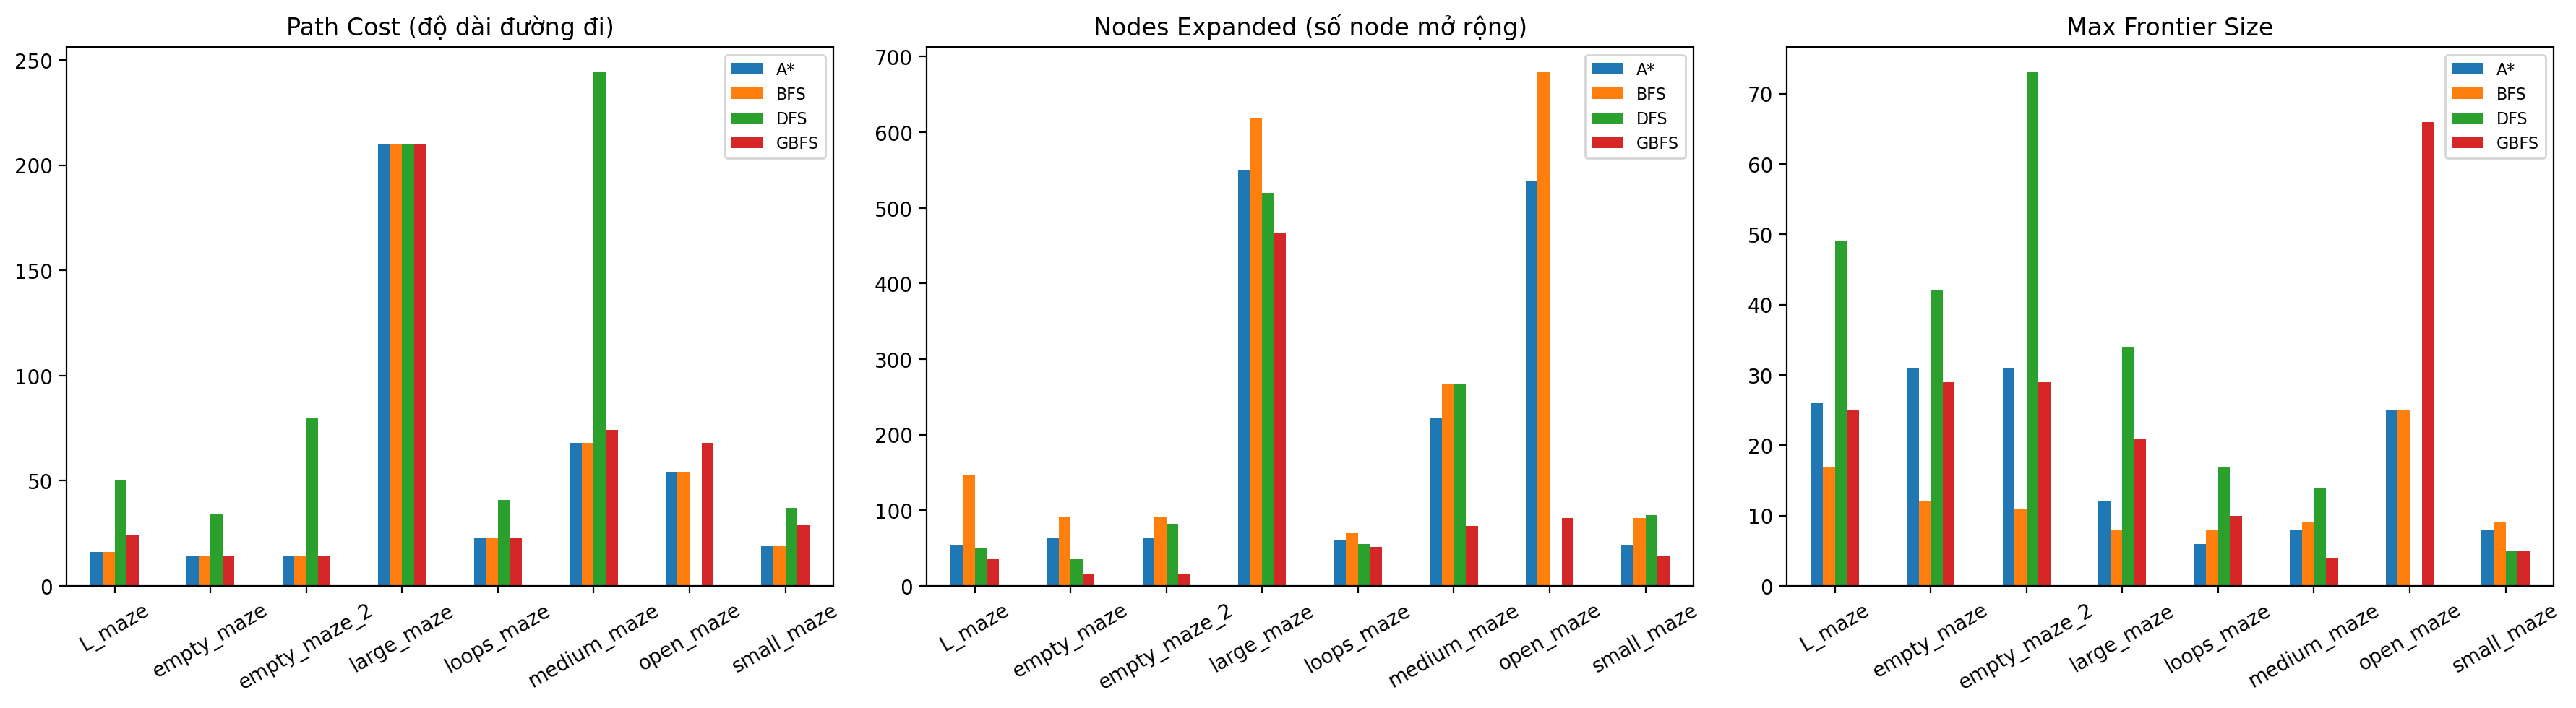

In [56]:
import matplotlib.pyplot as plt
import pandas as pd

df_num = df.copy()
for col in ['Path Cost', 'Nodes Expanded', 'Max Frontier']:
    df_num[col] = pd.to_numeric(df_num[col], errors='coerce')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ['Path Cost', 'Nodes Expanded', 'Max Frontier']
titles  = ['Path Cost (độ dài đường đi)', 'Nodes Expanded (số node mở rộng)', 'Max Frontier Size']

for ax, metric, title in zip(axes, metrics, titles):
    pivot = df_num.pivot(index='Maze', columns='Algorithm', values=metric)
    pivot.plot(kind='bar', ax=ax, rot=30)
    ax.set_title(title)
    ax.set_xlabel('')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


Discuss the most important lessons you have learned from implementing the different search strategies. 

### Bài học rút ra từ việc cài đặt các thuật toán tìm kiếm

1. **BFS luôn tìm được đường đi tối ưu** (path cost ngắn nhất) nhờ duyệt theo từng tầng, 
   nhưng tiêu tốn nhiều bộ nhớ nhất do phải lưu tập `reached` và toàn bộ `frontier`.

2. **DFS tiết kiệm bộ nhớ** hơn BFS rất nhiều ($O(b \cdot m)$ so với $O(b^d)$), 
   nhưng **không tối ưu** và thất bại ở các mê cung có không gian mở (`open_maze`) 
   vì cycle checking chỉ trên đường đi hiện tại là không đủ.

3. **GBFS tìm đích rất nhanh** (ít nodes expanded) nhờ heuristic dẫn hướng trực tiếp về đích, 
   nhưng đường đi tìm được thường **dài hơn** BFS và A* vì không quan tâm chi phí đã đi.

4. **A\* là thuật toán tốt nhất toàn diện**: vừa tối ưu (nhờ $f = g + h$ với heuristic admissible 
   là Manhattan distance), vừa tìm kiếm có định hướng nên nhanh hơn BFS trên thực tế.

5. **Heuristic chất lượng là yếu tố then chốt**: Manhattan distance phù hợp với mê cung 
   vì nó không bao giờ overestimate (admissible), đảm bảo A* tối ưu. 
   GBFS dùng cùng heuristic nhưng bỏ qua $g(n)$ nên mất tính tối ưu.


## Advanced task: IDS and Multiple goals

* __Graduate students__ need to complete this task [10 points]
* __Undergraduate students__ can attempt this as a bonus task [max +5 bonus points].

### IDS 
Implement IDS (iterative deepening search) using your DFS implementation. Test IDS on the mazes above. You may run into some issues with mazes with open spaces. If you cannot resolve the issues, then report and discuss what causes the problems.

In [ ]:
def dls(maze, node, goal, limit):
    """Depth-Limited Search - DFS với giới hạn độ sâu"""
    if node.pos == goal:
        return node, True  # found
    if node.cost >= limit:
        return None, True  # cutoff (chưa tìm thấy nhưng có thể sẽ tìm thấy)
    
    cutoff_occurred = False
    r, c = node.pos
    for action, (dr, dc) in MOVES.items():
        nr, nc = r + dr, c + dc
        if 0 <= nr < maze.shape[0] and 0 <= nc < maze.shape[1]:
            if maze[nr, nc] != 'X' and not _in_path(node, (nr, nc)):
                child = Node((nr, nc), node, action, node.cost + 1)
                result, cutoff = dls(maze, child, goal, limit)
                if result is not None:
                    return result, False
                if cutoff:
                    cutoff_occurred = True
    
    return None, cutoff_occurred


def ids(maze, start, goal, max_depth=500):
    """Iterative Deepening Search"""
    start, goal = tuple(start), tuple(goal)
    
    for depth in range(max_depth):
        root = Node(start, None, None, 0)
        result, cutoff = dls(maze, root, goal, depth)
        if result is not None:
            path = result.get_path_from_root()
            return {
                'path': path,
                'actions': [n.action for n in path if n.action],
                'nodes_expanded': depth,   # gần đúng
                'max_depth': depth,
                'max_frontier': depth,
                'reached': set()
            }
        if not cutoff:
            return None  # không có lời giải
    
    return None


In [58]:
# Thêm IDS vào dict algorithms
algorithms_ext = {'BFS': bfs, 'DFS': dfs, 'IDS': ids, 'GBFS': gbfs, 'A*': astar}

# Chạy lại run_algo với IDS (cùng wrapper)
for maze_file in ["small_maze.txt", "medium_maze.txt", "large_maze.txt"]:
    maze  = mh.parse_maze(open(maze_file).read())
    start = mh.find_pos(maze, 'S')
    goal  = mh.find_pos(maze, 'G')
    
    for name, fn in algorithms_ext.items():
        try:
            stats = run_algo(fn, maze, start, goal)
            print(f"{maze_file:<20} {name:<5} cost={stats['cost']}")
        except:
            print(f"{maze_file:<20} {name:<5} N/A*")


small_maze.txt       BFS   cost=19
small_maze.txt       DFS   cost=37
small_maze.txt       IDS   cost=19
small_maze.txt       GBFS  cost=29
small_maze.txt       A*    cost=19
medium_maze.txt      BFS   cost=68
medium_maze.txt      DFS   cost=244
medium_maze.txt      IDS   cost=68
medium_maze.txt      GBFS  cost=74
medium_maze.txt      A*    cost=68
large_maze.txt       BFS   cost=210
large_maze.txt       DFS   cost=210
large_maze.txt       IDS   cost=210
large_maze.txt       GBFS  cost=210
large_maze.txt       A*    cost=210


### Multiple Goals 
Create a few mazes with multiple goals by adding one or two more goals to the medium size maze. The agent is done when it finds one of the goals.
Solve the maze with your implementations for DFS, BFS, and IDS. Run experiments to show which implementations find the optimal solution and which do not. Discuss why that is the case.

=== BFS (multi-goal) ===
Path cost: 40, Nodes expanded: 149


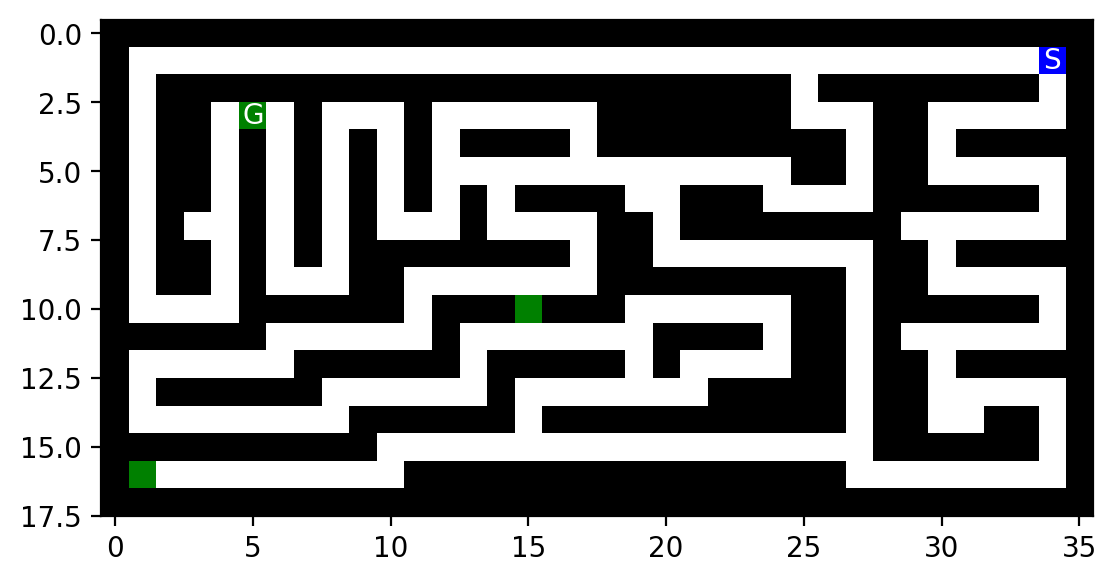

In [60]:
import copy

def add_extra_goals(maze_file, extra_goals):
    """Thêm ô đích phụ vào mê cung"""
    maze = mh.parse_maze(open(maze_file).read())
    m = maze.copy()
    for (r, c) in extra_goals:
        m[r, c] = 'G'
    return m

def bfs_multi(maze, start):
    """BFS với nhiều đích: dừng khi chạm vào bất kỳ ô G nào"""
    start = tuple(start)
    root  = Node(start, None, None, 0)
    frontier = deque([root])
    reached  = {start}
    nodes_expanded = 0

    while frontier:
        node = frontier.popleft()
        nodes_expanded += 1
        if maze[node.pos] == 'G':
            path = node.get_path_from_root()
            return {'path': path, 'actions': [n.action for n in path if n.action],
                    'nodes_expanded': nodes_expanded, 'max_depth': node.cost,
                    'max_frontier': len(frontier), 'reached': reached}
        r, c = node.pos
        for action, (dr, dc) in MOVES.items():
            nr, nc = r + dr, c + dc
            if 0 <= nr < maze.shape[0] and 0 <= nc < maze.shape[1]:
                if maze[nr, nc] != 'X' and (nr, nc) not in reached:
                    reached.add((nr, nc))
                    frontier.append(Node((nr, nc), node, action, node.cost + 1))
    return None

# Tạo mê cung với 2 đích phụ (chọn ô trống hợp lệ trong medium_maze)
maze_multi = add_extra_goals("medium_maze.txt", [(3, 5), (10, 15)])
start = mh.find_pos(maze_multi, 'S')

print("=== BFS (multi-goal) ===")
res = bfs_multi(maze_multi, start)
if res:
    print(f"Path cost: {len(res['actions'])}, Nodes expanded: {res['nodes_expanded']}")

mh.show_maze(maze_multi)


### Thảo luận: Tìm kiếm với nhiều đích

* **BFS** vẫn tối ưu: do duyệt theo tầng, nó luôn chạm đích gần nhất trước tiên → đường đi tìm được là ngắn nhất đến bất kỳ đích nào.
* **DFS** không tối ưu: có thể đi sâu vào nhánh dẫn tới đích xa hơn trước.
* **IDS** tối ưu: vì giống BFS về tính chất tìm đích theo độ sâu tăng dần → đích đầu tiên tìm thấy là đích gần nhất.


=== Minh họa thuật toán BFS trên small_maze ===


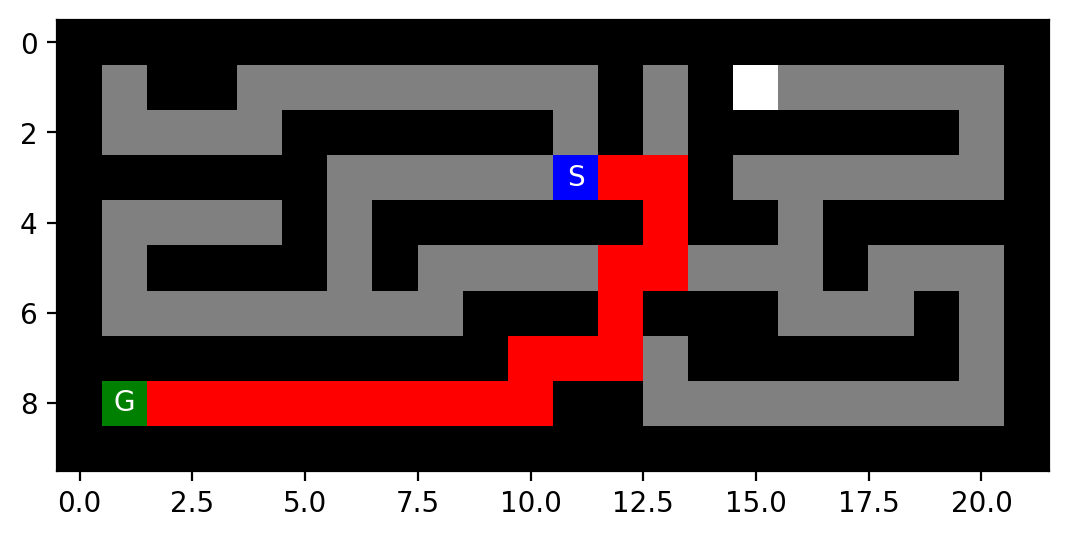

=== Minh họa thuật toán A* trên large_maze ===


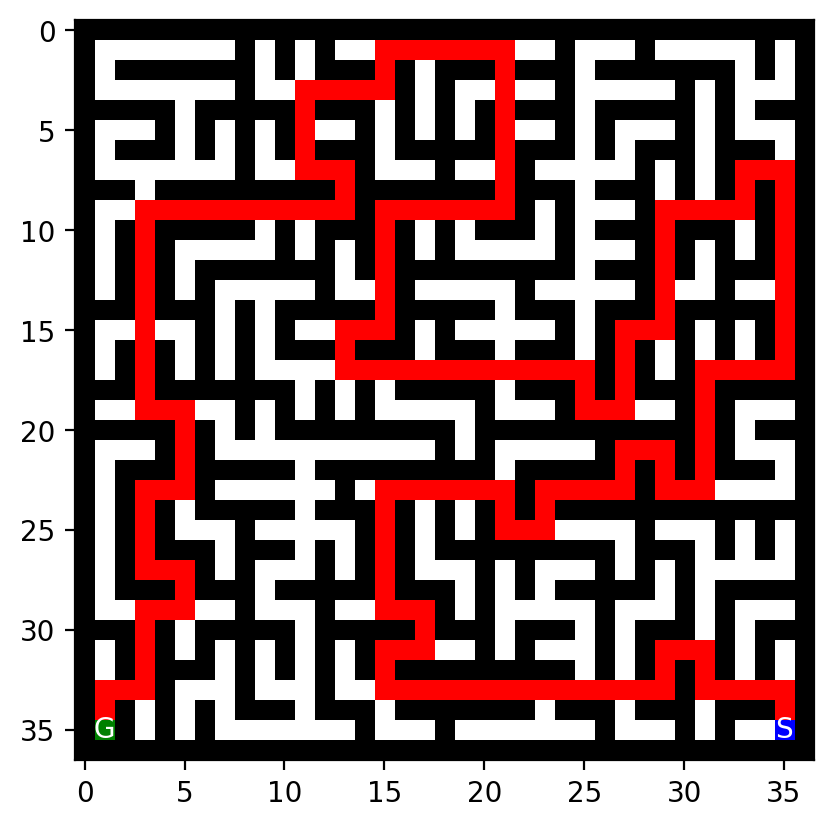

In [63]:
# ── Hiển thị trực quan bản đồ đường đi và vùng đã khám phá (Yêu cầu 3) ──

def draw_maze_result(algo_fn, maze_file, title):
    print(f"=== {title} ===")
    maze = mh.parse_maze(open(maze_file).read())
    start = mh.find_pos(maze, 'S')
    goal  = mh.find_pos(maze, 'G')
    
    result = algo_fn(maze, start, goal)
    
    path = []
    reached = set()
    
    # Lấy dữ liệu path và reached tùy theo output của thuật toán
    if isinstance(result, dict):
        path = result.get('path', [])
        reached = result.get('reached', set())
    else:
        node, stats = result
        path = node.get_path_from_root() if node else []
        reached = stats.get('reached', set())

    # Đánh dấu vùng trạng thái đã tìm kiếm bằng dấu '.'
    for pos in reached:
        if maze[pos] not in ['S', 'G', 'X']:
            maze[pos] = '.'
            
    # Đánh dấu đường đi cuối cùng bằng chữ 'P'
    for n in path:
        if n.pos and maze[n.pos] not in ['S', 'G', 'X']:
            maze[n.pos] = 'P'

    # Gọi hàm vẽ của maze_helper
    mh.show_maze(maze)

# Vẽ hình 1: BFS trên small_maze
draw_maze_result(bfs, "small_maze.txt", "Minh họa thuật toán BFS trên small_maze")

# Vẽ hình 2: A* trên large_maze
draw_maze_result(astar, "large_maze.txt", "Minh họa thuật toán A* trên large_maze")


## More Advanced Problems to Think About (not for credit)

If the assignment was to easy for yuo then you can think about the following problems. These problems are challenging and not part of this assignment. 

### Intersection as States
Instead of defining each square as a state, use only intersections as states. Now the storage requirement is reduced, but the path length between two intersections can be different. If we use total path length measured as the number of squares as path cost, how can we make sure that BFS and iterative deepening search is optimal? Change the code to do so.

In [53]:
# Your code/answer goes here

### Weighted A* search
Modify your A* search to add weights (see text book) and explore how different weights influence the result.

In [54]:
# Your code/answer goes here

### Unknown Maze
What happens if the agent does not know the layout of the maze in advance? This means that the agent faces an unknown environment, where it does not know the transition function. How does the environment look then (PEAS description)? How would you implement a rational agent to solve the maze? What if the agent still has a GPS device to tell the distance to the goal?

In [55]:
# Your code/answer goes here